# Domain Mismatch Evaluation

The experiment trains tokenizers on English C4 at each scale (10³–10⁸ characters) and evaluates them on **fixed** out-of-domain test holdouts (~10M chars each):

| Test domain | 
|-------------|
| Turkish (C4 `tr`) | 
| Code (CodeParrot) | 
| Chinese (C4 `zh`) | 

### Prerequisites
- Trained tokenizer checkpoints in `tokenizers/huggingface_tokenizers_16k_c4_{103..108}/`
- `evaluate.py` and `data.py` in the project root
- All four families: `bpe.json`, `unigram.json`, `wordpiece.json`, `wordlevel.json`


## 1. Setup


In [10]:
import sys
import json
import os
import subprocess
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "evaluate.py").exists():
    project_root = project_root / "CSE-599-Project"
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from data import load_preprocessed_dataset, save_dataset_dict

print(f"Project root: {project_root}")

dataset = "codeparrot"
datasetgraph = dataset
if dataset == "c4":
    datasetgraph = "c4-en"

VOCAB_SIZE   = 64_000          # 16k vocabulary
TEST_CHARS   = 10_000_000      # Fixed 10M-char test holdout 
TRAIN_SCALES = ["103", "104", "105", "106", "107", "108"]
FAMILIES     = ["bpe", "unigram", "wordpiece", "wordlevel"]

# Out-of-domain test corpora 
MISMATCH_DOMAINS = {
    "c4_en": {"dataset_name": "c4",  "config": "en", "chars": 11_000_000},
    "c4_tr":      {"dataset_name": "c4",           "config": "tr", "chars": 11_000_000},
    "c4_zh":      {"dataset_name": "c4",           "config": "zh", "chars": 11_000_000},
}
SPLIT_RATIOS = (0.0, 0.0, 1.0)  # trailing 10M chars as test (see data.py)

data_dir    = project_root / "data"
results_dir = project_root / "results" / "domain_mismatch"
results_dir.mkdir(parents=True, exist_ok=True)

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"Test holdout    : {TEST_CHARS:,} chars")
print(f"Training scales : {TRAIN_SCALES}")
print(f"Mismatch domains: {list(MISMATCH_DOMAINS)}")

Project root: C:\Users\darby\Downloads\CSE 599\Project
Vocabulary size : 64000
Test holdout    : 10,000,000 chars
Training scales : ['103', '104', '105', '106', '107', '108']
Mismatch domains: ['c4_en', 'c4_tr', 'c4_zh']


In [11]:
from superbpe.utils import construct_hf_tokenizer
from transformers import AutoTokenizer
import os

SUPERBPE_ROOT = Path(fr"C:\Users\darby\Downloads\CSE 599\Project\SuperBPE Tokenizers\{dataset}")

# Collect all 16000_c4_* checkpoint directories
superbpe_ckpt_dirs = sorted(
    p for p in SUPERBPE_ROOT.glob(f"{VOCAB_SIZE}_{dataset}_*") if p.is_dir()
)

print(f"Found {len(superbpe_ckpt_dirs)} SuperBPE checkpoint(s):")
for ckpt in superbpe_ckpt_dirs:
    print(f"  {ckpt.name}")

# Construct HF tokenizer files for each checkpoint
print("\nConstructing HuggingFace tokenizers...")
for ckpt in superbpe_ckpt_dirs:
    print(f"  {ckpt.name} ...", end=" ", flush=True)
    try:
        construct_hf_tokenizer(str(ckpt))
        print("done.")
    except Exception as e:
        print(f"FAILED: {e}")

# Load each constructed tokenizer with AutoTokenizer
print("\nLoading SuperBPE tokenizers with AutoTokenizer...")
superbpe_tokenizers = {}
for ckpt in superbpe_ckpt_dirs:
    print(f"  {ckpt.name} ...", end=" ", flush=True)
    try:
        tok = AutoTokenizer.from_pretrained(str(ckpt))
        superbpe_tokenizers[ckpt.name] = tok
        print(f"loaded (vocab size: {tok.vocab_size}).")
    except Exception as e:
        print(f"FAILED: {e}")

print(f"\n{len(superbpe_tokenizers)} SuperBPE tokenizer(s) ready.")


Found 6 SuperBPE checkpoint(s):
  64000_codeparrot_103
  64000_codeparrot_104
  64000_codeparrot_105
  64000_codeparrot_106
  64000_codeparrot_107
  64000_codeparrot_108

Constructing HuggingFace tokenizers...
  64000_codeparrot_103 ... done.
  64000_codeparrot_104 ... done.
  64000_codeparrot_105 ... done.
  64000_codeparrot_106 ... done.
  64000_codeparrot_107 ... done.
  64000_codeparrot_108 ... done.

Loading SuperBPE tokenizers with AutoTokenizer...
  64000_codeparrot_103 ... loaded (vocab size: 454).
  64000_codeparrot_104 ... loaded (vocab size: 2040).
  64000_codeparrot_105 ... loaded (vocab size: 8471).
  64000_codeparrot_106 ... loaded (vocab size: 64000).
  64000_codeparrot_107 ... loaded (vocab size: 64000).
  64000_codeparrot_108 ... loaded (vocab size: 64000).

6 SuperBPE tokenizer(s) ready.


## 2. Verify Existing Tokenizer Checkpoints

Confirm all four families exist at every training scale before running evaluation.


In [12]:
ckpt_root = project_root / "tokenizers"
missing = []

print(f"{'Scale':<8} {'Family':<12} {'Status'}")
print("-" * 35)

for scale in TRAIN_SCALES:
    ckpt_dir = ckpt_root / f"{dataset}/huggingface_tokenizers_{VOCAB_SIZE}_{dataset}_{scale}"
    for family in FAMILIES:
        path = ckpt_dir / f"{family}.json"
        status = "✓" if path.exists() else "✗ MISSING"
        if not path.exists():
            missing.append(str(path))
        print(f"10^{scale[-1] if len(scale)==3 else scale}  {family:<12} {status}")

if missing:
    print(f"\n⚠ {len(missing)} checkpoint(s) missing — train before evaluating.")
else:
    print("\nAll checkpoints present.")

Scale    Family       Status
-----------------------------------
10^3  bpe          ✓
10^3  unigram      ✓
10^3  wordpiece    ✓
10^3  wordlevel    ✓
10^4  bpe          ✓
10^4  unigram      ✓
10^4  wordpiece    ✓
10^4  wordlevel    ✓
10^5  bpe          ✓
10^5  unigram      ✓
10^5  wordpiece    ✓
10^5  wordlevel    ✓
10^6  bpe          ✓
10^6  unigram      ✓
10^6  wordpiece    ✓
10^6  wordlevel    ✓
10^7  bpe          ✓
10^7  unigram      ✓
10^7  wordpiece    ✓
10^7  wordlevel    ✓
10^8  bpe          ✓
10^8  unigram      ✓
10^8  wordpiece    ✓
10^8  wordlevel    ✓

All checkpoints present.


## 3. Materialize Out-of-Domain Test Corpora

The paper uses a **fixed test holdout** independent of tokenizer training.
We stream each corpus, discard the train/val portion, and keep only the
trailing ~10M characters as the test split.

Skip any domain whose `test.jsonl` already exists.


In [13]:
import datasets

for domain, cfg in MISMATCH_DOMAINS.items():
    out_dir  = data_dir / f"{domain}_corpus"
    test_file = out_dir / "test.jsonl"

    if test_file.exists():
        size_mb = test_file.stat().st_size / 1024 / 1024
        print(f"✓ {domain}: test.jsonl already exists ({size_mb:.1f} MB) — skipping.")
        continue

    print(f"\nMaterializing {domain}  ({cfg['chars']:,} chars) ...")
    kwargs = dict(
        dataset_name     = cfg["dataset_name"],
        full_dataset_chars = cfg["chars"],
        split_ratios     = SPLIT_RATIOS,
        seed             = 13,
        streaming        = True,
    )
    if cfg["config"]:
        kwargs["config"] = cfg["config"]

    try:
        dataset = load_preprocessed_dataset(**kwargs)
        save_dataset_dict(dataset, out_dir, file_format="jsonl")
        size_mb = test_file.stat().st_size / 1024 / 1024
        print(f"  ✓ Saved → {test_file}  ({size_mb:.1f} MB)")
    except Exception as e:
        print(f"  ✗ Failed: {e}")

print("\nDone.")

✓ c4_en: test.jsonl already exists (26.4 MB) — skipping.
✓ c4_tr: test.jsonl already exists (27.0 MB) — skipping.
✓ c4_zh: test.jsonl already exists (53.0 MB) — skipping.

Done.


## 4. Run Domain-Mismatch Evaluation

For every (scale × family) checkpoint, evaluate against each out-of-domain test corpus using `evaluate.py`.

Results are written to `results/domain_mismatch/<domain>/<scale>/<family>.json`.

**Note:** Each scale on a 10M-char OOD corpus takes several minutes. Scales with all four `{family}.json` files are skipped automatically; re-run this cell to fill in missing scales (106–108 if not yet complete).


In [14]:
evaluate_script = project_root / "evaluate.py"

for domain in MISMATCH_DOMAINS:
    test_file = data_dir / f"{domain}_corpus" / "test.jsonl"
    if not test_file.exists():
        print(f"⚠ {domain}: test.jsonl missing — run cell 3 first.")
        continue

    print(f"\n{'='*55}")
    print(f"Domain: {domain}")
    print(f"{'='*55}")

    for scale in TRAIN_SCALES:
        ckpt_dir = (
            project_root
            / "tokenizers"
            / "codeparrot"
            / f"huggingface_tokenizers_{VOCAB_SIZE}_{dataset}_{scale}"
        )
        out_dir = results_dir / domain / scale
        out_dir.mkdir(parents=True, exist_ok=True)

        # Skip if all family results already written
        if all((out_dir / f"{f}.json").exists() for f in FAMILIES):
            print(f"  scale {scale}: already evaluated — skipping.")
            continue

        if not ckpt_dir.exists():
            print(f"  scale {scale}: checkpoint dir missing — skipping.")
            continue

        print(f"  scale {scale} ...", end=" ", flush=True)
        result = subprocess.run(
            [
                sys.executable, str(evaluate_script),
                "--tokenizer", str(ckpt_dir),
                "--test",      str(test_file),
                "--max-order", "5",
                "--output",    str(out_dir),
            ],
            capture_output=True, text=True,
        )
        if result.returncode == 0:
            print("done.")
        else:
            print(f"FAILED\n{result.stderr[-400:]}")

print("\nEvaluation complete.")


print("\nRunning SuperBPE evaluations...")
for domain in MISMATCH_DOMAINS:
    test_file = data_dir / f"{domain}_corpus" / "test.jsonl"
    if not test_file.exists():
        print(f"⚠ {domain}: test.jsonl missing — run cell 3 first.")
        continue

    print(f"\n{'='*55}")
    print(f"Domain: {domain} (SuperBPE)")
    print(f"{'='*55}")

    for ckpt in superbpe_ckpt_dirs:
        out_dir = results_dir / domain / ckpt.name
        out_dir.mkdir(parents=True, exist_ok=True)

        if (out_dir / "superbpe.json").exists():
            print(f"  {ckpt.name}: already evaluated — skipping.")
            continue

        if ckpt.name not in superbpe_tokenizers:
            print(f"  {ckpt.name}: tokenizer not loaded — skipping.")
            continue

        print(f"  {ckpt.name} ...", end=" ", flush=True)
        result = subprocess.run(
            [
                sys.executable, str(evaluate_script),
                "--tokenizer", str(ckpt),
                "--test",      str(test_file),
                "--max-order", "5",
                "--output",    str(out_dir),
            ],
            capture_output=True, text=True,
        )
        if result.returncode == 0:
            # evaluate.py writes <family>.json; rename to superbpe.json
            written = list(out_dir.glob("*.json"))
            if written and written[0].name != "superbpe.json":
                written[0].rename(out_dir / "superbpe.json")
            print("done.")
        else:
            print(f"FAILED\n{result.stderr[-400:]}")


Domain: c4_en
  scale 103 ... done.
  scale 104 ... done.
  scale 105 ... done.
  scale 106 ... done.
  scale 107 ... done.
  scale 108 ... done.

Domain: c4_tr
  scale 103 ... done.
  scale 104 ... done.
  scale 105 ... done.
  scale 106 ... done.
  scale 107 ... done.
  scale 108 ... done.

Domain: c4_zh
  scale 103 ... done.
  scale 104 ... done.
  scale 105 ... done.
  scale 106 ... done.
  scale 107 ... done.
  scale 108 ... done.

Evaluation complete.

Running SuperBPE evaluations...

Domain: c4_en (SuperBPE)
  64000_codeparrot_103 ... done.
  64000_codeparrot_104 ... done.
  64000_codeparrot_105 ... done.
  64000_codeparrot_106 ... done.
  64000_codeparrot_107 ... done.
  64000_codeparrot_108 ... done.

Domain: c4_tr (SuperBPE)
  64000_codeparrot_103 ... done.
  64000_codeparrot_104 ... done.
  64000_codeparrot_105 ... done.
  64000_codeparrot_106 ... done.
  64000_codeparrot_107 ... done.
  64000_codeparrot_108 ... done.

Domain: c4_zh (SuperBPE)
  64000_codeparrot_103 ... don

## 5. Collect Results

Aggregate all JSON outputs into a single DataFrame for plotting.


In [15]:
import pandas as pd

ARCHIVE_DATA = project_root / rf"data/{dataset}-20260603T050249Z-3-001/{dataset}"
SCALE_TOTAL_CHARS = {
    "103": 1_000,
    "104": 10_000,
    "105": 100_000,
    "106": 1_000_000,
    "107": 10_000_000,
    "108": 100_000_000,
}
TRAIN_CHAR_FRACTION = 0.8

FAMILIES     = ["bpe", "unigram", "wordpiece", "wordlevel", "superbpe"]

def train_chars_for_scale(scale: str) -> int:
    for train_path in (
        ARCHIVE_DATA / f"{dataset}_{scale}" / "train.jsonl",
        project_root / f"data/{dataset}_{scale}" / "train.jsonl",
    ):
        if train_path.is_file():
            return sum(len(json.loads(line)["text"]) for line in train_path.open(encoding="utf-8"))
    return int(SCALE_TOTAL_CHARS[scale] * TRAIN_CHAR_FRACTION)


rows = []
for domain in MISMATCH_DOMAINS:
    for scale in TRAIN_SCALES:
        out_dir = results_dir / domain / scale
        for family in FAMILIES:
            result_file = out_dir / f"{family}.json"
            if not result_file.exists():
                continue
            with result_file.open() as f:
                m = json.load(f)
            row = {
                "domain":            domain,
                "scale":             scale,
                "train_chars":       train_chars_for_scale(scale),
                "family":            family,
                "compression_ratio": m["compression_ratio"],
            }
            for k, v in m["entropies_bits_per_token"].items():
                row[f"entropy_{k}"] = v
            for k, v in m["entropy_rates_bits_per_char"].items():
                row[f"rate_{k}"] = v
            rows.append(row)

df = pd.DataFrame(rows)
print(f"{len(df)} result(s) loaded across scales {sorted(df['scale'].unique()) if len(df) else []}.")
df.head()

72 result(s) loaded across scales ['103', '104', '105', '106', '107', '108'].


,domain,scale,train_chars,family,compression_ratio,entropy_H1,entropy_H2,entropy_H3,entropy_H4,entropy_H5,rate_H1,rate_H2,rate_H3,rate_H4,rate_H5
0,c4_en,103,804,bpe,1.831000,6.201563,5.119490,4.025235,2.825938,1.779873,3.405092,2.810959,2.210136,1.551638,0.977275
1,c4_en,103,804,unigram,1.664257,5.859022,4.868987,3.879726,2.863871,1.964179,3.539328,2.941266,2.343672,1.730012,1.186525
2,c4_en,103,804,wordpiece,1.805605,6.588899,5.017327,3.785214,2.672289,1.759031,3.668650,2.793611,2.107579,1.487910,0.979415
3,c4_en,103,804,wordlevel,5.030005,2.716091,2.442777,2.350201,2.278458,2.179201,0.542865,0.488238,0.469735,0.455396,0.435557
4,c4_en,104,8005,bpe,2.204932,7.242960,5.659269,4.015822,2.454843,1.369517,3.302456,2.580366,1.831030,1.119295,0.624437


## 6. Plot — Compression Ratio Under Domain Mismatch

for each tokenizer family, split by out-of-domain test corpus.

**Expected behaviour**: unlike the in-domain curves, CR does not
consistently improve with more English training data.


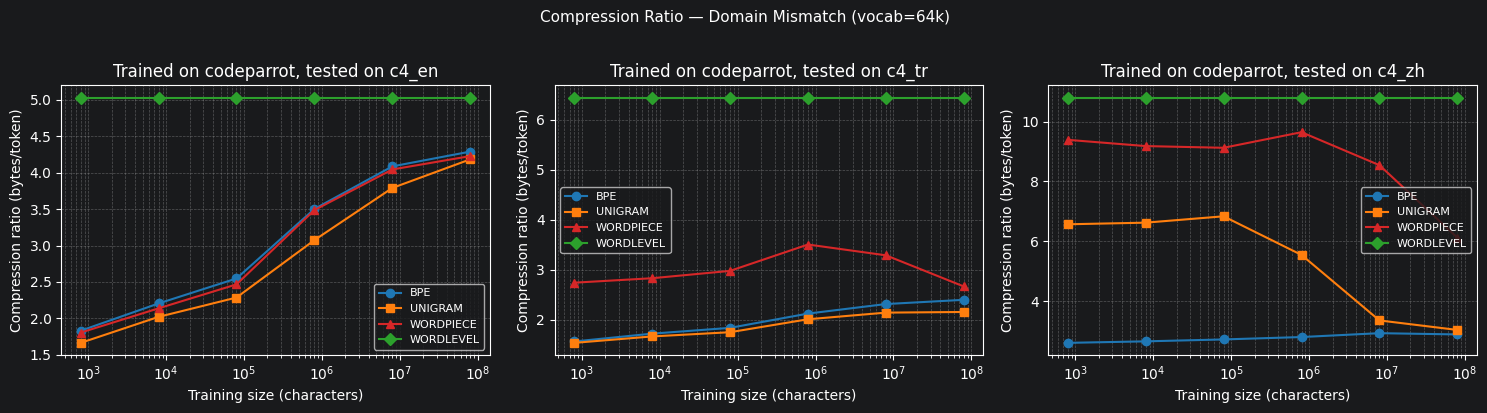

Saved → C:\Users\darby\Downloads\CSE 599\Project\results\domain_mismatch\fig5_compression_mismatch.png


In [16]:
import matplotlib.pyplot as plt

FAMILY_STYLE = {
    "bpe":       {"color": "tab:blue",   "marker": "o"},
    "unigram":   {"color": "tab:orange", "marker": "s"},
    "wordpiece": {"color": "tab:red",    "marker": "^"},
    "wordlevel": {"color": "tab:green",  "marker": "D"},
    "superbpe": {"color": "tab:purple",  "marker": "+"},
}

domains_to_plot = [d for d in MISMATCH_DOMAINS if d in df["domain"].unique()]
if not domains_to_plot:
    print("No results yet — run evaluation cells first.")
else:
    fig, axes = plt.subplots(1, len(domains_to_plot),
                             figsize=(5 * len(domains_to_plot), 4),
                             sharey=False)
    if len(domains_to_plot) == 1:
        axes = [axes]
    for ax, domain in zip(axes, domains_to_plot):
        sub = df[df["domain"] == domain].sort_values("train_chars")
        for family, style in FAMILY_STYLE.items():
            fam = sub[sub["family"] == family]
            if fam.empty:
                continue
            ax.plot(
                fam["train_chars"], fam["compression_ratio"],
                label=family.upper(), **style,
            )
        ax.set_xscale("log")
        ax.set_xlabel("Training size (characters)")
        ax.set_ylabel("Compression ratio (bytes/token)")
        ax.set_title(f"Trained on {datasetgraph}, tested on {domain}")
        ax.legend(fontsize=8)
        ax.grid(True, which="both", ls="--", alpha=0.4)

    plt.suptitle(
        f"Compression Ratio — Domain Mismatch (vocab={VOCAB_SIZE//1000}k)",
        fontsize=11, y=1.02,
    )
    plt.tight_layout()
    plt.savefig(results_dir / "fig5_compression_mismatch.png", dpi=150, bbox_inches="tight")


    plt.show()
    print(f"Saved → {results_dir / 'fig5_compression_mismatch.png'}")

## 7. Plot — k-gram Entropies Under Domain Mismatch

**Expected behaviour**: H2–H5 remain elevated (bounded away from zero)
unlike the in-domain case where they collapse toward zero.


C:\Users\darby\AppData\Local\Temp\ipykernel_24256\1130076915.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, ncol=2)


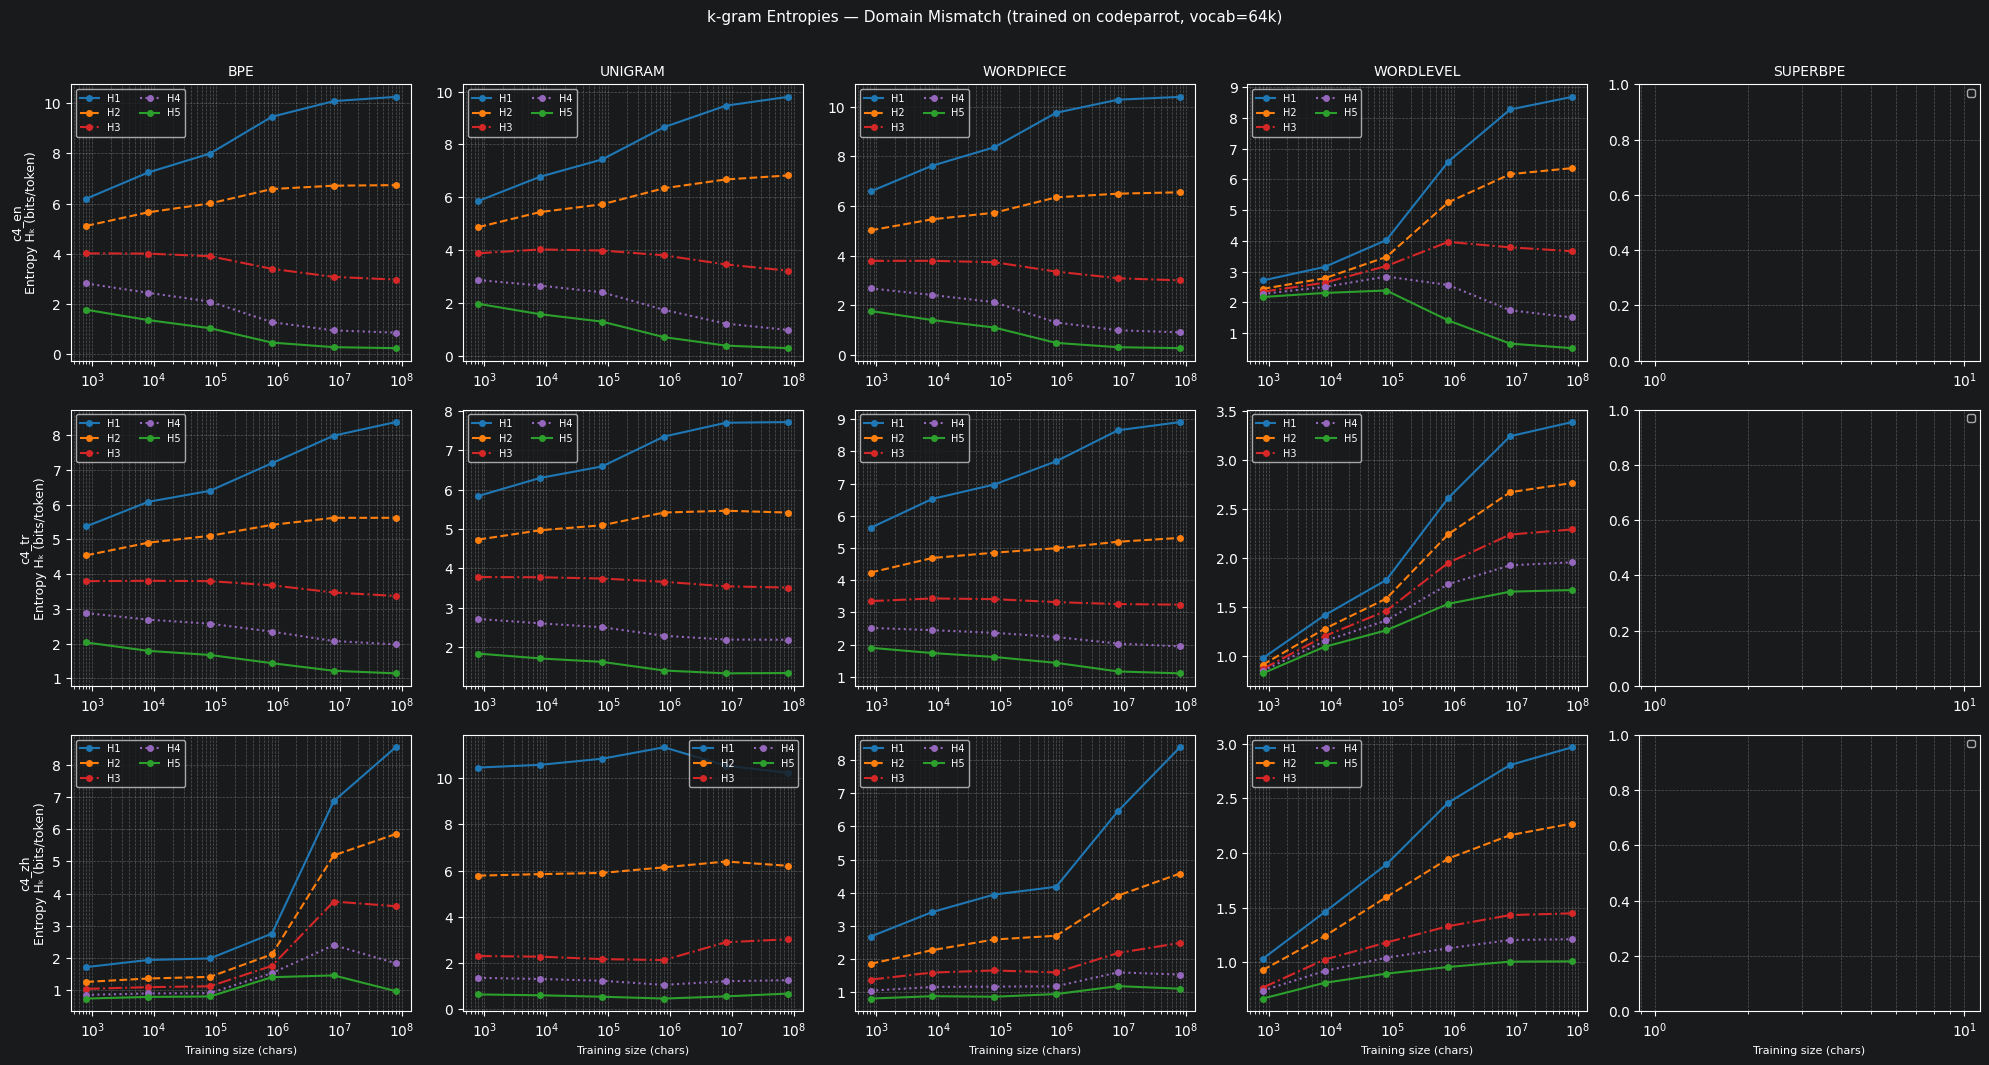

Saved → C:\Users\darby\Downloads\CSE 599\Project\results\domain_mismatch\fig6_entropy_mismatch.png


In [17]:
ORDER_STYLE = {
    "H1": {"color": "tab:blue",   "ls": "-"},
    "H2": {"color": "tab:orange", "ls": "--"},
    "H3": {"color": "tab:red",    "ls": "-."},
    "H4": {"color": "tab:purple", "ls": ":"},
    "H5": {"color": "tab:green",  "ls": "-"},
}

if domains_to_plot:
    n_domains = len(domains_to_plot)
    n_families = len(FAMILIES)
    fig, axes = plt.subplots(
        n_domains, n_families,
        figsize=(4 * n_families, 3.5 * n_domains),
        sharex=False, sharey=False,
    )
    # Ensure 2-D indexing
    if n_domains == 1:
        axes = [axes]
    if n_families == 1:
        axes = [[row] for row in axes]

    for row_idx, domain in enumerate(domains_to_plot):
        sub = df[df["domain"] == domain].sort_values("train_chars")
        for col_idx, family in enumerate(FAMILIES):
            ax = axes[row_idx][col_idx]
            fam = sub[sub["family"] == family]
            for order, style in ORDER_STYLE.items():
                col = f"entropy_{order}"
                if col not in fam.columns or fam[col].isna().all():
                    continue
                ax.plot(
                    fam["train_chars"], fam[col],
                    label=order, marker="o", markersize=4, **style,
                )
            ax.set_xscale("log")
            if col_idx == 0:
                ax.set_ylabel(f"{domain}\nEntropy Hₖ (bits/token)", fontsize=9)
            if row_idx == 0:
                ax.set_title(family.upper(), fontsize=10)
            if row_idx == n_domains - 1:
                ax.set_xlabel("Training size (chars)", fontsize=8)
            ax.legend(fontsize=7, ncol=2)
            ax.grid(True, which="both", ls="--", alpha=0.4)

    plt.suptitle(
        f"k-gram Entropies — Domain Mismatch (trained on {datasetgraph}, vocab={VOCAB_SIZE//1000}k)",
        fontsize=11, y=1.01,
    )
    plt.tight_layout()
    plt.savefig(results_dir / "fig6_entropy_mismatch.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {results_dir / 'fig6_entropy_mismatch.png'}")

## 8. Save Aggregated Results Table


In [18]:
if not df.empty:
    csv_path = results_dir / "domain_mismatch_results.csv"
    df.to_csv(csv_path, index=False)
    print(f"Saved {len(df)} rows → {csv_path}")
    print(df.to_string(index=False))
else:
    print("DataFrame is empty — run evaluation cells first.")

Saved 72 rows → C:\Users\darby\Downloads\CSE 599\Project\results\domain_mismatch\domain_mismatch_results.csv
domain scale  train_chars    family  compression_ratio  entropy_H1  entropy_H2  entropy_H3  entropy_H4  entropy_H5  rate_H1  rate_H2  rate_H3  rate_H4  rate_H5
 c4_en   103          804       bpe           1.831000    6.201563    5.119490    4.025235    2.825938    1.779873 3.405092 2.810959 2.210136 1.551638 0.977275
 c4_en   103          804   unigram           1.664257    5.859022    4.868987    3.879726    2.863871    1.964179 3.539328 2.941266 2.343672 1.730012 1.186525
 c4_en   103          804 wordpiece           1.805605    6.588899    5.017327    3.785214    2.672289    1.759031 3.668650 2.793611 2.107579 1.487910 0.979415
 c4_en   103          804 wordlevel           5.030005    2.716091    2.442777    2.350201    2.278458    2.179201 0.542865 0.488238 0.469735 0.455396 0.435557
 c4_en   104         8005       bpe           2.204932    7.242960    5.659269    4.015822 